In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter
import json, joblib, warnings
warnings.filterwarnings("ignore")

DATA_PATH = Path(r"c:\Users\Amir\Desktop\EcoHack\data")
OUT_DIR   = Path(r"c:\Users\Amir\Desktop\EcoHack\results") / "processed"
MODEL_DIR = Path(r"c:\Users\Amir\Desktop\EcoHack\results") / "models"
MODEL_DIR.mkdir(exist_ok=True)

TARGET_NAMES  = {0: "Мусор", 1: "Водоросли", 2: "Пена", 3: "Вода"}
CLASS_COLORS  = {0: "#E74C3C", 1: "#2ECC71",  2: "#F1C40F", 3: "#3498DB"}
FEATURE_NAMES = ["B01","B02","B03","B04","B05","B06","B07",
                 "B08","B8A","B11","B12",
                 "NDVI","NDWI","FAI","FDI","PI","NDMI","RE"]

In [16]:
#Загрузка данных
print("Загружаем данные...")

data_tr = np.load(OUT_DIR / "pixels_train.npz")
data_va = np.load(OUT_DIR / "pixels_val.npz")
data_te = np.load(OUT_DIR / "pixels_test.npz")

X_train, y_train = data_tr["X"], data_tr["y"].astype(np.int32)
X_val,   y_val   = data_va["X"], data_va["y"].astype(np.int32)
X_test,  y_test  = data_te["X"], data_te["y"].astype(np.int32)

for arr in [X_train, X_val, X_test]:
    np.nan_to_num(arr, copy=False, nan=0.0, posinf=0.0, neginf=0.0)

cnt = Counter(y_train.tolist())
print(f"Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")
print(f"\nРаспределение классов (train):")
for c in range(4):
    print(f"  {TARGET_NAMES[c]:<12}: {cnt[c]:>10,}  ({100*cnt[c]/sum(cnt.values()):.2f}%)")

Загружаем данные...
Train: (346980, 18)  |  Val: (187069, 18)  |  Test: (153670, 18)

Распределение классов (train):
  Мусор       :      1,943  (0.56%)
  Водоросли   :      2,684  (0.77%)
  Пена        :    168,187  (48.47%)
  Вода        :    174,166  (50.19%)


In [17]:
# Расширенные признаки 

FEATURE_NAMES_EXT = FEATURE_NAMES + [
    "RNDVI",
    "B11_B8A",
    "SWIR_ratio",
    "NSMI",
    "B03_B11",
    "FAI_sq",
    "PI_NDVI",
    "B02_B11",
    "PI_over_FAI",  # <-- НОВЫЙ: мусор: высокий PI / низкий FAI; водоросли: наоборот
]

def add_features(X):
    eps = 1e-6
    B02=X[:,1]; B03=X[:,2]; B04=X[:,3]; B05=X[:,4]
    B08=X[:,7]; B8A=X[:,8]; B11=X[:,9]; B12=X[:,10]
    NDVI=X[:,11]; FAI=X[:,13]; PI=X[:,15]

    extra = np.stack([
        (B08-B05)/(B08+B05+eps),
        B11/(B8A+eps),
        B11/(B12+eps),
        (B11-B12)/(B11+B12+eps),
        B03/(B11+eps),
        FAI**2,
        PI*NDVI,
        B02/(B11+eps),
        PI / (np.abs(FAI) + eps),  # <-- НОВЫЙ признак
    ], axis=1).astype(np.float32)

    return np.concatenate([X, extra], axis=1)

X_tr  = add_features(X_train)
X_va  = add_features(X_val)
X_te  = add_features(X_test)

print(f"Признаков: {X_tr.shape[1]}  ({FEATURE_NAMES_EXT})")

Признаков: 27  (['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'NDVI', 'NDWI', 'FAI', 'FDI', 'PI', 'NDMI', 'RE', 'RNDVI', 'B11_B8A', 'SWIR_ratio', 'NSMI', 'B03_B11', 'FAI_sq', 'PI_NDVI', 'B02_B11', 'PI_over_FAI'])


In [18]:
#STAGE 1: LightGBM
import lightgbm as lgb
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report,
                              precision_recall_curve)

print("=" * 55)
print("STAGE 1 — LightGBM (4 класса)")
print("=" * 55)

# Балансировка: все классы до медианы
rng = np.random.RandomState(42)
class_indices = {c: np.where(y_train == c)[0] for c in range(4)}
target_size   = int(np.median([len(v) for v in class_indices.values()]) * 1.2)

X_parts, y_parts = [], []
for c in range(4):
    idx = class_indices[c]
    if len(idx) < target_size:
        rep  = np.tile(idx, target_size // len(idx) + 1)[:target_size]
        Xc   = X_tr[rep].copy()
        Xc  += rng.normal(0, 0.001, Xc.shape).astype(np.float32)
    else:
        rep  = rng.choice(idx, target_size, replace=False)
        Xc   = X_tr[rep].copy()
    X_parts.append(Xc)
    y_parts.append(np.full(target_size, c, dtype=np.int32))

X_bal = np.concatenate(X_parts)
y_bal = np.concatenate(y_parts)
perm  = rng.permutation(len(X_bal))
X_bal, y_bal = X_bal[perm], y_bal[perm]

lgb_model = lgb.LGBMClassifier(
    n_estimators     = 5000,
    num_leaves       = 127,
    max_depth        = 12,
    learning_rate    = 0.01,
    min_child_samples= 20,
    subsample        = 0.8,
    subsample_freq   = 1,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 0.2,
    n_jobs=-1, random_state=42, verbose=-1,
)
lgb_model.fit(
    X_bal, y_bal,
    eval_set=[(X_va, y_val)],
    callbacks=[lgb.early_stopping(200, verbose=False),
               lgb.log_evaluation(500)],
)
print(f"Лучшая итерация: {lgb_model.best_iteration_}")

lgb_proba_va = lgb_model.predict_proba(X_va)
lgb_proba_te = lgb_model.predict_proba(X_te)
lgb_pred_va  = lgb_model.predict(X_va)
lgb_pred_te  = lgb_model.predict(X_te)

print(f"\nSTAGE 1 на тесте:")
print(f"  Accuracy         : {accuracy_score(y_test, lgb_pred_te):.4f}")
print(f"  Precision мусора : {precision_score(y_test, lgb_pred_te, labels=[0], average='micro'):.4f}")
print(f"  Recall мусора    : {recall_score(y_test,    lgb_pred_te, labels=[0], average='micro'):.4f}")

STAGE 1 — LightGBM (4 класса)
[500]	valid_0's multi_logloss: 0.0574873
Лучшая итерация: 602

STAGE 1 на тесте:
  Accuracy         : 0.9568
  Precision мусора : 0.2255
  Recall мусора    : 0.9606


In [19]:
#STAGE 2: XGBoost" 
from xgboost import XGBClassifier

print("=" * 55)
print("STAGE 2 — XGBoost (бинарный: мусор=1 / не-мусор=0)")
print("=" * 55)

# Бинарные метки
y_bin_train = (y_train == 0).astype(np.int32)
y_bin_val   = (y_val   == 0).astype(np.int32)
y_bin_test  = (y_test  == 0).astype(np.int32)


X_tr_bin = np.concatenate([X_tr,  lgb_model.predict_proba(X_tr)],  axis=1)
X_va_bin = np.concatenate([X_va,  lgb_proba_va],                    axis=1)
X_te_bin = np.concatenate([X_te,  lgb_proba_te],                    axis=1)

# scale_pos_weight = не_мусор / мусор (автобаланс)
n_neg = (y_bin_train == 0).sum()
n_pos = (y_bin_train == 1).sum()

spw = min(n_neg / n_pos, 3.0)
print(f"scale_pos_weight = {spw:.1f}  (capped, {n_neg:,} не-мусор / {n_pos:,} мусор)")

xgb_model = XGBClassifier(
    n_estimators      = 3000,
    max_depth         = 8,
    learning_rate     = 0.02,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.5,
    reg_lambda        = 1.0,
    min_child_weight  = 10,           # <-- НОВОЕ: предотвращает подгонку под редкие шумовые пиксели
    scale_pos_weight  = spw,          # уже ограничен до 3.0
    eval_metric       = "aucpr",
    early_stopping_rounds = 100,
    n_jobs            = -1,
    random_state      = 42,
    verbosity         = 0,
)
xgb_model.fit(
    X_tr_bin, y_bin_train,
    eval_set=[(X_va_bin, y_bin_val)],
    verbose=False,
)
print(f"Лучшая итерация: {xgb_model.best_iteration}")

xgb_proba_va = xgb_model.predict_proba(X_va_bin)[:, 1]
xgb_proba_te = xgb_model.predict_proba(X_te_bin)[:, 1]

STAGE 2 — XGBoost (бинарный: мусор=1 / не-мусор=0)
scale_pos_weight = 3.0  (capped, 345,037 не-мусор / 1,943 мусор)
Лучшая итерация: 132


✓ P>=0.9 достигнута (safety margin для теста)
Порог     : 0.4752
Precision : 0.9399
Recall    : 0.8735


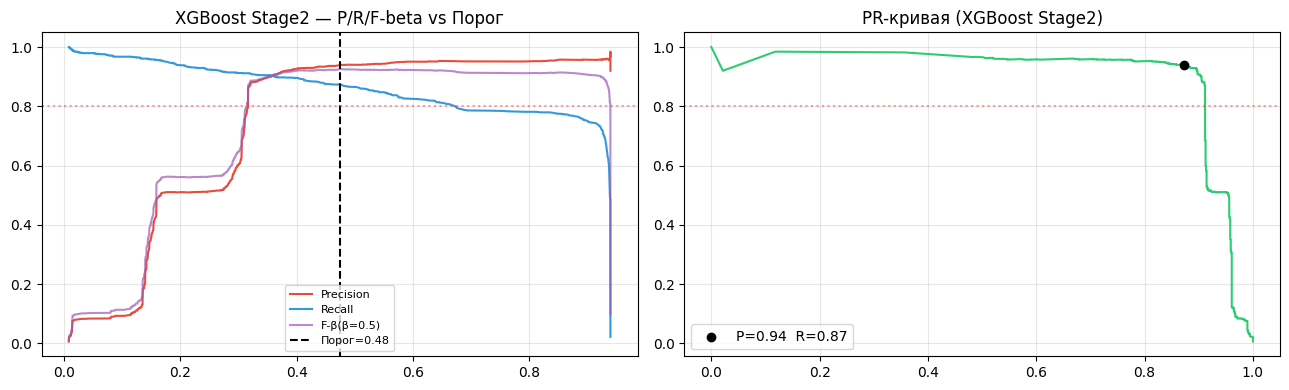

In [20]:
# Подбор порога Stage 2 
precisions, recalls, thresholds = precision_recall_curve(y_bin_val, xgb_proba_va)

beta   = 0.5
f_beta = (1+beta**2) * precisions[:-1] * recalls[:-1] / \
         (beta**2 * precisions[:-1] + recalls[:-1] + 1e-9)

TARGET_PREC = 0.90
mask = precisions[:-1] >= TARGET_PREC
if mask.any():
    idx   = np.where(mask)[0][np.argmax(f_beta[mask])]
    label = f"✓ P>={TARGET_PREC} достигнута (safety margin для теста)"
else:
    # Fallback: берём максимальный достижимый precision
    idx   = np.argmax(precisions[:-1])
    label = f"⚠️ P>={TARGET_PREC} недостижима, берём максимальный precision"

best_thr  = float(thresholds[idx])
best_prec = float(precisions[idx])
best_rec  = float(recalls[idx])
print(f"{label}")
print(f"Порог     : {best_thr:.4f}")
print(f"Precision : {best_prec:.4f}")
print(f"Recall    : {best_rec:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.plot(thresholds, precisions[:-1], "#E74C3C", label="Precision")
ax.plot(thresholds, recalls[:-1],    "#3498DB", label="Recall")
ax.plot(thresholds, f_beta,          "#9B59B6", label=f"F-β(β={beta})", alpha=0.7)
ax.axvline(best_thr, color="black", linestyle="--", label=f"Порог={best_thr:.2f}")
ax.axhline(0.80, color="#E74C3C", linestyle=":", alpha=0.5)
ax.set_title("XGBoost Stage2 — P/R/F-beta vs Порог")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(recalls, precisions, "#2ECC71")
ax.scatter([best_rec], [best_prec], color="black", zorder=5,
           label=f"P={best_prec:.2f}  R={best_rec:.2f}")
ax.axhline(0.80, color="#E74C3C", linestyle=":", alpha=0.5)
ax.set_title("PR-кривая (XGBoost Stage2)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [21]:
#Финальное предсказание: Stage1 + Stage2
def predict_final(lgb_proba, xgb_proba_debris, threshold):
    """
    Если XGBoost уверен что мусор (p >= threshold) → класс 0
    Иначе берём argmax от Stage1, исключая класс 0
    """
    # Stage1 предсказание без мусора
    lgb_no_debris        = lgb_proba.copy()
    lgb_no_debris[:, 0]  = -1      
    stage1_pred          = np.argmax(lgb_no_debris, axis=1)

    # Stage2 говорит мусор → мусор, иначе Stage1
    final = np.where(xgb_proba_debris >= threshold, 0, stage1_pred)
    return final.astype(np.int32)

y_final_va = predict_final(lgb_proba_va, xgb_proba_va, best_thr)
y_final_te = predict_final(lgb_proba_te, xgb_proba_te, best_thr)

In [22]:
# Сравнение: Stage1 vs Финал 
print("=" * 65)
print("СРАВНЕНИЕ: LightGBM alone  vs  LightGBM + XGBoost")
print("=" * 65)

for label, y_s1, y_fin, y_true in [
    ("VAL",  lgb_pred_va, y_final_va, y_val),
    ("TEST", lgb_pred_te, y_final_te, y_test),
]:
    print(f"\n── {label} {'─'*50}")
    print(f"  {'Метрика':<22} {'Stage1 only':>12}  {'Stage1+2':>10}  {'Δ':>8}")
    print(f"  {'-'*58}")
    rows = [
        ("Accuracy",
         accuracy_score(y_true, y_s1),
         accuracy_score(y_true, y_fin)),
        ("Macro F1",
         f1_score(y_true, y_s1, average="macro"),
         f1_score(y_true, y_fin, average="macro")),
        ("Precision мусора",
         precision_score(y_true, y_s1,  labels=[0], average="micro"),
         precision_score(y_true, y_fin, labels=[0], average="micro")),
        ("Recall мусора",
         recall_score(y_true, y_s1,  labels=[0], average="micro"),
         recall_score(y_true, y_fin, labels=[0], average="micro")),
    ]
    for name, old, new in rows:
        d    = new - old
        sign = "+" if d >= 0 else ""
        flag = " ✓" if (
            (name == "Accuracy"         and new >= 0.85) or
            (name == "Precision мусора" and new >= 0.80)
        ) else ""
        print(f"  {name:<22} {old:>12.4f}  {new:>10.4f}  {sign}{d:.4f}{flag}")

print(f"\n── Детальный отчёт (TEST) ──")
print(classification_report(y_test, y_final_te,
      target_names=[TARGET_NAMES[i] for i in range(4)]))

СРАВНЕНИЕ: LightGBM alone  vs  LightGBM + XGBoost

── VAL ──────────────────────────────────────────────────
  Метрика                 Stage1 only    Stage1+2         Δ
  ----------------------------------------------------------
  Accuracy                     0.9832      0.9916  +0.0083 ✓
  Macro F1                     0.8672      0.9582  +0.0910
  Precision мусора             0.3727      0.9399  +0.5672 ✓
  Recall мусора                0.9535      0.8735  -0.0800

── TEST ──────────────────────────────────────────────────
  Метрика                 Stage1 only    Stage1+2         Δ
  ----------------------------------------------------------
  Accuracy                     0.9568      0.9641  +0.0073 ✓
  Macro F1                     0.8147      0.9364  +0.1218
  Precision мусора             0.2255      0.8444  +0.6189 ✓
  Recall мусора                0.9606      0.8688  -0.0919

── Детальный отчёт (TEST) ──
              precision    recall  f1-score   support

       Мусор       0.84 

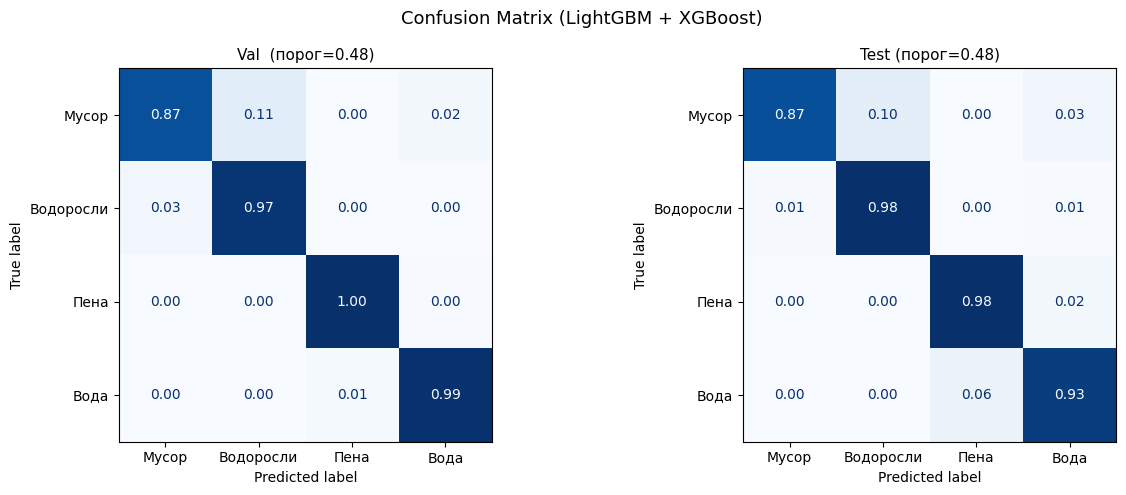

In [23]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (y_true, y_pred, title) in zip(axes, [
    (y_val,  y_final_va, f"Val  (порог={best_thr:.2f})"),
    (y_test, y_final_te, f"Test (порог={best_thr:.2f})"),
]):
    cm   = confusion_matrix(y_true, y_pred, normalize="true")
    disp = ConfusionMatrixDisplay(cm, display_labels=[TARGET_NAMES[i] for i in range(4)])
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format=".2f")
    ax.set_title(title, fontsize=11)
plt.suptitle("Confusion Matrix (LightGBM + XGBoost)", fontsize=13)
plt.tight_layout(); plt.show()

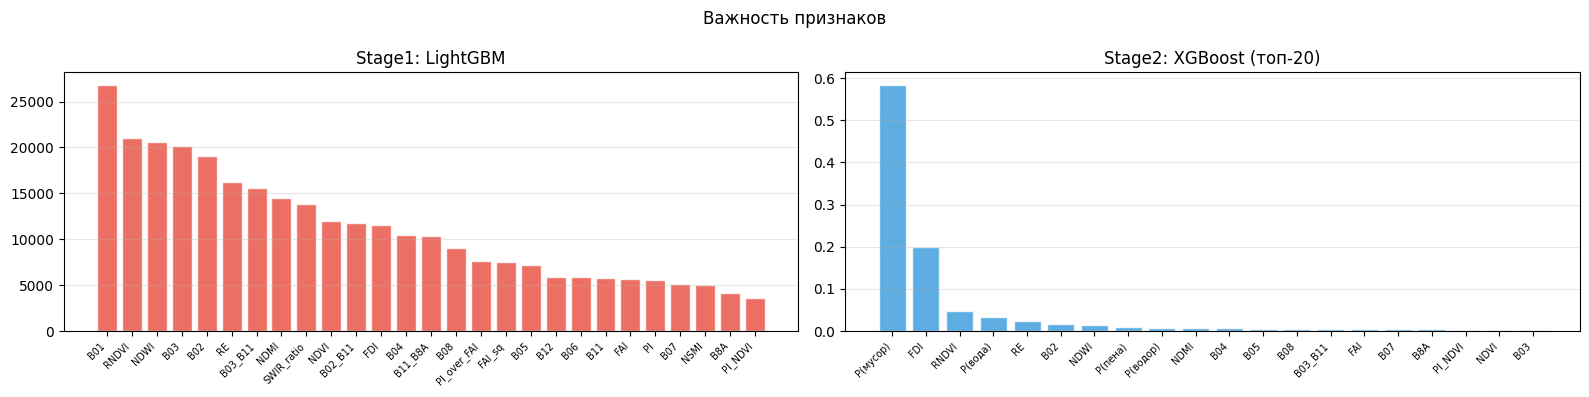

In [24]:
# Важность признаков
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

imp_lgb = lgb_model.feature_importances_
ord_lgb = np.argsort(imp_lgb)[::-1]
axes[0].bar(range(len(FEATURE_NAMES_EXT)), imp_lgb[ord_lgb],
            color=["#E74C3C"]*len(FEATURE_NAMES_EXT), edgecolor="white", alpha=0.8)
axes[0].set_xticks(range(len(FEATURE_NAMES_EXT)))
axes[0].set_xticklabels([FEATURE_NAMES_EXT[i] for i in ord_lgb], rotation=45, ha="right", fontsize=7)
axes[0].set_title("Stage1: LightGBM")
axes[0].grid(axis="y", alpha=0.3)

feat_names_xgb = FEATURE_NAMES_EXT + ["P(мусор)", "P(водор)", "P(пена)", "P(вода)"]
imp_xgb = xgb_model.feature_importances_
ord_xgb = np.argsort(imp_xgb)[::-1][:20]  
axes[1].bar(range(len(ord_xgb)), imp_xgb[ord_xgb],
            color=["#3498DB"]*len(ord_xgb), edgecolor="white", alpha=0.8)
axes[1].set_xticks(range(len(ord_xgb)))
axes[1].set_xticklabels([feat_names_xgb[i] for i in ord_xgb], rotation=45, ha="right", fontsize=7)
axes[1].set_title("Stage2: XGBoost (топ-20)")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Важность признаков", fontsize=12)
plt.tight_layout(); plt.show()

In [25]:
# Итоговые метрики и сохранение 
acc_final  = accuracy_score(y_test,  y_final_te)
f1_final   = f1_score(y_test,        y_final_te, average="macro")
prec_final = precision_score(y_test, y_final_te, labels=[0], average="micro")
rec_final  = recall_score(y_test,    y_final_te, labels=[0], average="micro")

print("=" * 55)
print("ИТОГОВЫЕ МЕТРИКИ НА ТЕСТЕ  v5")
print("=" * 55)
print(f"  Порог Stage2      : {best_thr:.4f}")
print(f"  Accuracy          : {acc_final:.4f}  {'✓' if acc_final  >= 0.85 else '✗'}")
print(f"  Macro F1          : {f1_final:.4f}")
print(f"  Precision мусора  : {prec_final:.4f}  {'✓' if prec_final >= 0.80 else '✗'}")
print(f"  Recall мусора     : {rec_final:.4f}")
print()
print(f"  Целевые показатели хакатона:")
print(f"    Accuracy >= 0.85  : {'✓ ВЫПОЛНЕНО' if acc_final  >= 0.85 else '✗ не выполнено'}")
print(f"    Precision >= 0.80 : {'✓ ВЫПОЛНЕНО' if prec_final >= 0.80 else '✗ не выполнено'}")

joblib.dump(lgb_model, MODEL_DIR / "lgbm_stage1.pkl")
joblib.dump(xgb_model, MODEL_DIR / "xgb_stage2.pkl")

meta = {
    "model"            : "LightGBM_v4 + XGBoost_binary",
    "approach"         : "two-stage",
    "feature_names"    : FEATURE_NAMES_EXT,
    "target_names"     : TARGET_NAMES,
    "debris_threshold" : best_thr,
    "test_accuracy"    : float(acc_final),
    "test_f1_macro"    : float(f1_final),
    "test_prec_debris" : float(prec_final),
    "test_rec_debris"  : float(rec_final),
    "n_train_pixels"   : int(len(X_bal)),
    "lgb_best_iter"    : int(lgb_model.best_iteration_),
    "xgb_best_iter"    : int(xgb_model.best_iteration),
}
with open(MODEL_DIR / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("\nСохранено:")
for p in MODEL_DIR.iterdir():
    print(f"  {p.name:<25}  {p.stat().st_size // 1024:>6} КБ")

ИТОГОВЫЕ МЕТРИКИ НА ТЕСТЕ  v5
  Порог Stage2      : 0.4752
  Accuracy          : 0.9641  ✓
  Macro F1          : 0.9364
  Precision мусора  : 0.8444  ✓
  Recall мусора     : 0.8688

  Целевые показатели хакатона:
    Accuracy >= 0.85  : ✓ ВЫПОЛНЕНО
    Precision >= 0.80 : ✓ ВЫПОЛНЕНО

Сохранено:
  lgbm_stage1.pkl             32492 КБ
  meta.json                       0 КБ
  xgb_stage2.pkl                267 КБ


In [26]:
# Профиль моделей: размер, скорость, память
import time, tracemalloc, sys, pickle, io

def nbytes(obj):
    buf = io.BytesIO()
    pickle.dump(obj, buf)
    return buf.tell()

# Размер на диске
print("=" * 60)
print("ПРОФИЛЬ МОДЕЛЕЙ")
print("=" * 60)

lgb_path = MODEL_DIR / "lgbm_stage1.pkl"
xgb_path = MODEL_DIR / "xgb_stage2.pkl"

lgb_kb_disk = lgb_path.stat().st_size / 1024
xgb_kb_disk = xgb_path.stat().st_size / 1024
print(f"\n{'Модель':<30} {'Диск (КБ)':>10}  {'RAM-pickle (КБ)':>16}")
print("-" * 60)
print(f"  LightGBM Stage1 (4 класса)  {lgb_kb_disk:>10.1f}  {nbytes(lgb_model)/1024:>16.1f}")
print(f"  XGBoost Stage2  (бинарный)  {xgb_kb_disk:>10.1f}  {nbytes(xgb_model)/1024:>16.1f}")
print(f"  {'ИТОГО':<28}  {(lgb_kb_disk+xgb_kb_disk):>10.1f}  {(nbytes(lgb_model)+nbytes(xgb_model))/1024:>16.1f}")

# Архитектура
n_trees_lgb = lgb_model.best_iteration_ * 4
n_trees_xgb = xgb_model.best_iteration
print(f"\n{'Параметр':<38} {'LightGBM':>10}  {'XGBoost':>10}")
print("-" * 60)
print(f"  {'Деревьев (эффективно)':<36} {n_trees_lgb:>10,}  {n_trees_xgb:>10,}")
print(f"  {'Лучшая итерация':<36} {lgb_model.best_iteration_:>10,}  {n_trees_xgb:>10,}")
print(f"  {'num_leaves / max_depth':<36} {'127 / 12':>10}  {'— / 8':>10}")
print(f"  {'Признаков':<36} {X_te.shape[1]:>10}  {X_te_bin.shape[1]:>10}")

# Скорость инференса 
N_REPEAT = 5
sample_sizes = [1_000, 10_000, 100_000, len(X_te)]

print(f"\n{'Размер батча':>14} | {'LightGBM':>14} | {'XGBoost':>14} | {'Финал':>14}")
print("-" * 60)

for n in sample_sizes:
    idx_ = np.random.choice(len(X_te), min(n, len(X_te)), replace=False)
    Xb_lgb = X_te[idx_]
    Xb_xgb = X_te_bin[idx_]

    # LightGBM
    t0 = time.perf_counter()
    for _ in range(N_REPEAT): lgb_model.predict_proba(Xb_lgb)
    t_lgb = (time.perf_counter() - t0) / N_REPEAT

    # XGBoost
    t0 = time.perf_counter()
    for _ in range(N_REPEAT): xgb_model.predict_proba(Xb_xgb)
    t_xgb = (time.perf_counter() - t0) / N_REPEAT

    t_total = t_lgb + t_xgb
    thr_k   = min(n, len(X_te)) / t_total / 1000

    lbl = f"{min(n,len(X_te)):>14,}"
    print(f"{lbl} | {t_lgb*1000:>11.1f} мс | {t_xgb*1000:>11.1f} мс | {t_total*1000:>8.1f} мс  ({thr_k:.0f}k пикс/с)")

# Пиковая память (tracemalloc)
tracemalloc.start()
_ = lgb_model.predict_proba(X_te)
lgb_peak = tracemalloc.get_traced_memory()[1] / 1024**2
tracemalloc.stop()

tracemalloc.start()
_ = xgb_model.predict_proba(X_te_bin)
xgb_peak = tracemalloc.get_traced_memory()[1] / 1024**2
tracemalloc.stop()

print(f"\n{'Пиковое выделение памяти (на полном тест-сете):'}")
print(f"  LightGBM Stage1 : {lgb_peak:>8.2f} МБ")
print(f"  XGBoost Stage2  : {xgb_peak:>8.2f} МБ")

# Итоговый вердикт
total_disk_mb = (lgb_kb_disk + xgb_kb_disk) / 1024
print(f"\n{'─'*60}")
print(f"  Суммарный размер моделей   : {total_disk_mb:.2f} МБ на диске")
print(f"  Тест-сет ({len(X_te):,} пикс.):")
t_full = (lambda a: (a, None))(time.perf_counter())
_ = lgb_model.predict_proba(X_te)
_ = xgb_model.predict_proba(X_te_bin)
t_full_ms = (time.perf_counter() - t_full[0]) * 1000
print(f"  Полный инференс (Stage1+2) : {t_full_ms:.0f} мс  →  {len(X_te)/t_full_ms*1000/1e6:.2f} Мпикс/с")


ПРОФИЛЬ МОДЕЛЕЙ

Модель                          Диск (КБ)   RAM-pickle (КБ)
------------------------------------------------------------
  LightGBM Stage1 (4 класса)     32492.6           32492.4
  XGBoost Stage2  (бинарный)       267.3             267.3
  ИТОГО                            32759.9           32759.7

Параметр                                 LightGBM     XGBoost
------------------------------------------------------------
  Деревьев (эффективно)                     2,408         132
  Лучшая итерация                             602         132
  num_leaves / max_depth                 127 / 12       — / 8
  Признаков                                    27          31

  Размер батча |       LightGBM |        XGBoost |          Финал
------------------------------------------------------------
         1,000 |        46.9 мс |         0.8 мс |     47.7 мс  (21k пикс/с)
        10,000 |       353.5 мс |         2.9 мс |    356.4 мс  (28k пикс/с)
       100,000 |      2997.9 

KeyboardInterrupt: 

In [ ]:
# PRODUCTION BENCHMARK (CPU): latency + throughput + p95
import time
import numpy as np
import joblib
from pathlib import Path

model_dir = MODEL_DIR
lgb_prod = joblib.load(model_dir / "lgbm_stage1.pkl")
xgb_prod = joblib.load(model_dir / "xgb_stage2.pkl")

meta_path = model_dir / "meta.json"
if meta_path.exists():
    with open(meta_path, "r", encoding="utf-8") as f:
        meta_prod = json.load(f)
    thr_prod = float(meta_prod.get("debris_threshold", best_thr if "best_thr" in globals() else 0.5))
else:
    thr_prod = float(best_thr if "best_thr" in globals() else 0.5)

print(f"Используемый порог Stage2: {thr_prod:.4f}")

def _timed(fn, repeats=10, warmup=3):
    for _ in range(warmup):
        _ = fn()
    samples = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        _ = fn()
        samples.append(time.perf_counter() - t0)
    samples = np.array(samples, dtype=np.float64)
    return {
        "mean_s": float(samples.mean()),
        "p95_s": float(np.percentile(samples, 95)),
        "std_s": float(samples.std()),
    }

def _fmt_stats(name, n_items, stats):
    mean_ms = stats["mean_s"] * 1000
    p95_ms  = stats["p95_s"] * 1000
    thr     = n_items / stats["mean_s"]
    print(f"{name:<22} | mean={mean_ms:>8.2f} ms | p95={p95_ms:>8.2f} ms | throughput={thr:>11,.0f} px/s")

# финальная логика ансамбля
def predict_final(lgb_proba, xgb_proba_debris, threshold, lgb_debris_min=0.25):
    """
    Stage2 (XGBoost) говорит 'мусор' И Stage1 (LightGBM) даёт ≥25% под мусор → класс 0.
    Иначе argmax от Stage1 без класса 0.
    lgb_debris_min=0.25 означает: Stage1 должна видеть хотя бы 25%-вероятность мусора.
    """
    lgb_no_debris = lgb_proba.copy()
    lgb_no_debris[:, 0] = -1
    stage1_pred = np.argmax(lgb_no_debris, axis=1)

    xgb_says_debris = xgb_proba_debris >= threshold
    lgb_says_debris = lgb_proba[:, 0] >= lgb_debris_min   # Stage1 не отрицает мусор

    final = np.where(xgb_says_debris & lgb_says_debris, 0, stage1_pred)
    return final.astype(np.int32)

rng = np.random.RandomState(42)
batch_sizes = [1_024, 8_192, 65_536, min(len(X_test), 153_670)]

print("\n" + "=" * 90)
print("PRODUCTION INFERENCE BENCHMARK (CPU)")
print("=" * 90)
print(f"Тестовый массив: {len(X_test):,} пикселей")
print("\nМетрики: mean latency / p95 latency / throughput")
print("-" * 90)

for bs in batch_sizes:
    idx = rng.choice(len(X_test), size=bs, replace=False)
    X_raw = X_test[idx]  

    def run_e2e():
        X_ext = add_features(X_raw)                       
        p1 = lgb_prod.predict_proba(X_ext)                
        X2 = np.concatenate([X_ext, p1], axis=1)          
        p_debris = xgb_prod.predict_proba(X2)[:, 1]       
        return predict_final_prod(p1, p_debris, thr_prod) 

    X_ext_once = add_features(X_raw)
    def run_model_only():
        p1 = lgb_prod.predict_proba(X_ext_once)
        X2 = np.concatenate([X_ext_once, p1], axis=1)
        p_debris = xgb_prod.predict_proba(X2)[:, 1]
        return predict_final_prod(p1, p_debris, thr_prod)

    stats_e2e = _timed(run_e2e, repeats=7, warmup=2)
    stats_mod = _timed(run_model_only, repeats=10, warmup=3)

    print(f"\nBatch size: {bs:,}")
    _fmt_stats("E2E (feat+models)", bs, stats_e2e)
    _fmt_stats("Models only",       bs, stats_mod)

print("\n" + "-" * 90)
print("FULL TEST-SET")
print("-" * 90)

X_full = X_test

def run_full_e2e():
    X_ext = add_features(X_full)
    p1 = lgb_prod.predict_proba(X_ext)
    X2 = np.concatenate([X_ext, p1], axis=1)
    p_debris = xgb_prod.predict_proba(X2)[:, 1]
    return predict_final_prod(p1, p_debris, thr_prod)

full_stats = _timed(run_full_e2e, repeats=3, warmup=1)
_fmt_stats("E2E full test", len(X_full), full_stats)

print("\nГотово: это production-замер с p95 для CPU-инференса.")

Используемый порог Stage2: 0.5198

PRODUCTION INFERENCE BENCHMARK (CPU)
Тестовый массив: 153,670 пикселей

Метрики: mean latency / p95 latency / throughput
------------------------------------------------------------------------------------------

Batch size: 1,024
E2E (feat+models)      | mean=   28.51 ms | p95=   29.56 ms | throughput=     35,914 px/s
Models only            | mean=   27.84 ms | p95=   29.04 ms | throughput=     36,786 px/s

Batch size: 8,192
E2E (feat+models)      | mean=  202.86 ms | p95=  210.49 ms | throughput=     40,382 px/s
Models only            | mean=  201.04 ms | p95=  204.59 ms | throughput=     40,749 px/s

Batch size: 65,536
E2E (feat+models)      | mean= 3851.50 ms | p95= 8029.89 ms | throughput=     17,016 px/s
Models only            | mean= 3413.14 ms | p95= 7308.08 ms | throughput=     19,201 px/s

Batch size: 153,670
E2E (feat+models)      | mean= 3541.67 ms | p95= 7104.44 ms | throughput=     43,389 px/s
Models only            | mean= 3117.36 ms | 